<a href="https://colab.research.google.com/github/ekarsilodh/EHR_Mapping/blob/main/Preprocessing%2C_Feature_Engineering%2C_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install icd-mappings

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 33.3 MB/s eta 0:00:00
  Attempting uninstall: importlib-resources
    Found existing installation: importlib_resources 6.5.2
    Uninstalling importlib_resources-6.5.2:
      Successfully uninstalled importlib_resources-6.5.2


In [ ]:
import pandas as pd
import numpy as np
import re
import ast
import json

In [ ]:
df_general = pd.read_csv('/content/drive/MyDrive/Mamun/patients_table.csv')
df_general = df_general.drop(columns=['Unnamed: 0'])
df_general.head()


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000690,F,86,2150,2008 - 2010,2152-01-30
1,10001919,M,59,2124,2017 - 2019,2124-12-20
2,10002667,F,58,2187,2020 - 2022,NaN
3,10007117,F,22,2189,2020 - 2022,NaN
4,10007174,M,70,2162,2011 - 2013,NaN


In [ ]:
df_admit = pd.read_csv('/content/drive/MyDrive/Mamun/patient_admissions.csv')
df_admit = df_admit.drop(columns=['Unnamed: 0'])
df_admit.head()


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000690,23280645,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,EW EMER.,P941QM,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0
1,10000690,25860671,2150-11-02 18:02:00,2150-11-12 13:45:00,NaN,EW EMER.,P26QQ4,EMERGENCY ROOM,REHAB,Medicare,English,WIDOWED,WHITE,2150-11-02 11:41:00,2150-11-02 19:37:00,0
2,10000690,26146595,2152-01-28 23:40:00,2152-01-30 15:56:00,NaN,EW EMER.,P61PLH,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,2152-01-28 15:41:00,2152-01-29 01:22:00,0
3,10000690,26504700,2150-07-03 02:46:00,2150-07-07 15:42:00,NaN,EW EMER.,P46JQK,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,2150-07-02 22:59:00,2150-07-03 03:55:00,0
4,10001919,29897682,2124-04-20 00:00:00,2124-04-21 13:47:00,NaN,SURGICAL SAME DAY ADMISSION,P64FA3,PHYSICIAN REFERRAL,HOME,Private,English,MARRIED,OTHER,NaN,NaN,0


In [ ]:
df_disease = pd.read_csv('/content/drive/MyDrive/Mamun/disease_diagnosis_code.csv')
df_disease = df_disease.drop(columns=['Unnamed: 0'])
df_disease.head()


,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000690,23280645,1,4280,9
1,10000690,23280645,2,486,9
2,10000690,23280645,3,4271,9
3,10000690,23280645,4,2764,9
4,10000690,23280645,5,42833,9


In [ ]:
df_merged_data = pd.merge(df_general, df_admit, on='subject_id', how='inner')
df_merged_data.head()

df_final_merged = pd.merge(df_merged_data, df_disease, on=['subject_id', 'hadm_id'], how='inner')
df_final_merged.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod,hadm_id,admittime,dischtime,deathtime,...,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,seq_num,icd_code,icd_version
0,10000690,F,86,2150,2008 - 2010,2152-01-30,23280645,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,1,4280,9
1,10000690,F,86,2150,2008 - 2010,2152-01-30,23280645,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,2,486,9
2,10000690,F,86,2150,2008 - 2010,2152-01-30,23280645,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,3,4271,9
3,10000690,F,86,2150,2008 - 2010,2152-01-30,23280645,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,4,2764,9
4,10000690,F,86,2150,2008 - 2010,2152-01-30,23280645,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,5,42833,9


In [ ]:
cols = df_final_merged.columns.tolist()
hadm_id_col = 'hadm_id'
subject_id_idx = cols.index('subject_id')

# Remove hadm_id from its current position
if hadm_id_col in cols:
    cols.remove(hadm_id_col)

# Insert hadm_id after subject_id
cols.insert(subject_id_idx + 1, hadm_id_col)

df_final_merged = df_final_merged[cols]
df_final_merged.head()

,subject_id,hadm_id,gender,anchor_age,anchor_year,anchor_year_group,dod,admittime,dischtime,deathtime,...,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,seq_num,icd_code,icd_version
0,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,1,4280,9
1,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,2,486,9
2,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,3,4271,9
3,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,4,2764,9
4,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,5,42833,9


In [ ]:
df_final_merged

,subject_id,hadm_id,gender,anchor_age,anchor_year,anchor_year_group,dod,admittime,dischtime,deathtime,...,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,seq_num,icd_code,icd_version
0,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,1,4280,9
1,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,2,486,9
2,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,3,4271,9
3,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,4,2764,9
4,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,5,42833,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137631,19999297,21439025,M,42,2162,2008 - 2010,2162-08-23,2162-08-14 23:55:00,2162-08-23 04:16:00,2162-08-23 04:16:00,...,Other,English,SINGLE,MULTIPLE RACE/ETHNICITY,2162-08-14 18:26:00,2162-08-15 02:01:00,1,12,30301,9
137632,19999297,21439025,M,42,2162,2008 - 2010,2162-08-23,2162-08-14 23:55:00,2162-08-23 04:16:00,2162-08-23 04:16:00,...,Other,English,SINGLE,MULTIPLE RACE/ETHNICITY,2162-08-14 18:26:00,2162-08-15 02:01:00,1,13,2768,9
137633,19999297,21439025,M,42,2162,2008 - 2010,2162-08-23,2162-08-14 23:55:00,2162-08-23 04:16:00,2162-08-23 04:16:00,...,Other,English,SINGLE,MULTIPLE RACE/ETHNICITY,2162-08-14 18:26:00,2162-08-15 02:01:00,1,14,3051,9
137634,19999297,21439025,M,42,2162,2008 - 2010,2162-08-23,2162-08-14 23:55:00,2162-08-23 04:16:00,2162-08-23 04:16:00,...,Other,English,SINGLE,MULTIPLE RACE/ETHNICITY,2162-08-14 18:26:00,2162-08-15 02:01:00,1,15,2874,9


In [ ]:
df_icd9_only = df_final_merged[df_final_merged['icd_version'] == 9]
df_icd9_only.head()

,subject_id,hadm_id,gender,anchor_age,anchor_year,anchor_year_group,dod,admittime,dischtime,deathtime,...,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,seq_num,icd_code,icd_version
0,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,1,4280,9
1,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,2,486,9
2,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,3,4271,9
3,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,4,2764,9
4,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,5,42833,9


# ICD Conversion

In [ ]:
from icdmappings import Mapper

mapper = Mapper()

In [ ]:
def normalize_dx(code):
    """Standardize diagnosis codes for mapping: uppercase, remove dots/spaces."""
    if pd.isna(code):
        return None
    s = str(code).strip().upper()
    s = s.replace('.', '')  # icdmappings works fine without dots
    s = re.sub(r'\s+', '', s)
    return s if s else None

def icd10_to_3char(icd10):
    """
    Reduce ICD-10 to 3-character category (letter + 2 digits).
    Examples: F0280 -> F02, H27.8 -> H27, I10 -> I10
    """
    if icd10 is None or (isinstance(icd10, float) and np.isnan(icd10)):
        return None
    s = str(icd10).strip().upper().replace('.', '')
    # Standard ICD-10 category pattern: 1 letter + 2 digits
    m = re.match(r'^([A-Z]\d{2})', s)
    return m.group(1) if m else None

In [ ]:
# Adjust these column names if yours differ
CODE_COL = "icd_code"
VER_COL  = "icd_version"   # set to None if you don't have it

df = df_final_merged.copy()

df["dx_norm"] = df[CODE_COL].apply(normalize_dx)

if VER_COL in df.columns:
    is_icd9  = df[VER_COL].astype(str).eq("9")
    is_icd10 = df[VER_COL].astype(str).eq("10")
else:
    # Heuristic: ICD-10 often starts with a letter; ICD-9 usually begins with a digit
    is_icd10 = df["dx_norm"].fillna("").str.match(r"^[A-Z]")
    is_icd9  = df["dx_norm"].fillna("").str.match(r"^\d")

In [ ]:
df["icd10_full"] = None

# Keep existing ICD-10 codes
df.loc[is_icd10, "icd10_full"] = df.loc[is_icd10, "dx_norm"]

# Map ICD-9 codes to ICD-10 (vectorized)
icd9_list = df.loc[is_icd9, "dx_norm"].tolist()
mapped_icd10 = mapper.map(icd9_list, source="icd9", target="icd10")  # returns list w/ None for invalids

df.loc[is_icd9, "icd10_full"] = mapped_icd10

In [ ]:
df["icd10_3char"] = df["icd10_full"].apply(icd10_to_3char)

# (Optional) quick QA
print("Total rows:", len(df))
print("ICD-9 mapped:", df.loc[is_icd9, "icd10_full"].notna().mean())
print("3-char non-null:", df["icd10_3char"].notna().mean())

# View unmapped ICD-9 codes
unmapped = df.loc[is_icd9 & df["icd10_full"].isna(), CODE_COL].value_counts().head(20)
print(unmapped)

Total rows: 137636
ICD-9 mapped: 0.9955950664744514
3-char non-null: 0.9901333953326165
icd_code
0414    39
9974    33
2841    26
V854    15
5185    15
2766    14
7806    14
V451    12
2874    11
7876     9
2740     9
7863     8
5997     8
2750     8
7955     8
4538     6
3488     5
7931     4
5128     3
7845     3
Name: count, dtype: int64


In [ ]:
df

,subject_id,hadm_id,gender,anchor_age,anchor_year,anchor_year_group,dod,admittime,dischtime,deathtime,...,race,edregtime,edouttime,hospital_expire_flag,seq_num,icd_code,icd_version,dx_norm,icd10_full,icd10_3char
0,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,1,4280,9,4280,I509,I50
1,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,2,486,9,486,J189,J18
2,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,3,4271,9,4271,I472,I47
3,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,4,2764,9,2764,E874,E87
4,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,5,42833,9,42833,I5033,I50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137631,19999297,21439025,M,42,2162,2008 - 2010,2162-08-23,2162-08-14 23:55:00,2162-08-23 04:16:00,2162-08-23 04:16:00,...,MULTIPLE RACE/ETHNICITY,2162-08-14 18:26:00,2162-08-15 02:01:00,1,12,30301,9,30301,F10229,F10
137632,19999297,21439025,M,42,2162,2008 - 2010,2162-08-23,2162-08-14 23:55:00,2162-08-23 04:16:00,2162-08-23 04:16:00,...,MULTIPLE RACE/ETHNICITY,2162-08-14 18:26:00,2162-08-15 02:01:00,1,13,2768,9,2768,E876,E87
137633,19999297,21439025,M,42,2162,2008 - 2010,2162-08-23,2162-08-14 23:55:00,2162-08-23 04:16:00,2162-08-23 04:16:00,...,MULTIPLE RACE/ETHNICITY,2162-08-14 18:26:00,2162-08-15 02:01:00,1,14,3051,9,3051,F17200,F17
137634,19999297,21439025,M,42,2162,2008 - 2010,2162-08-23,2162-08-14 23:55:00,2162-08-23 04:16:00,2162-08-23 04:16:00,...,MULTIPLE RACE/ETHNICITY,2162-08-14 18:26:00,2162-08-15 02:01:00,1,15,2874,9,2874,None,None


In [ ]:
print(f"Null values in 'icd10_full': {df['icd10_full'].isnull().sum()}")
print(f"Null values in 'icd10_3char': {df['icd10_3char'].isnull().sum()}")

Null values in 'icd10_full': 275
Null values in 'icd10_3char': 1358


In [ ]:
df = df.dropna(subset=['icd10_full']).copy()

In [ ]:
print(f"New number of rows after removing nulls in 'icd10_full': {len(df)}")
print(f"Null values in 'icd10_full' after dropping: {df['icd10_full'].isnull().sum()}")
print(f"Null values in 'icd10_3char' after dropping: {df['icd10_3char'].isnull().sum()}")

New number of rows after removing nulls in 'icd10_full': 137361
Null values in 'icd10_full' after dropping: 0
Null values in 'icd10_3char' after dropping: 1083


In [ ]:
df

,subject_id,hadm_id,gender,anchor_age,anchor_year,anchor_year_group,dod,admittime,dischtime,deathtime,...,race,edregtime,edouttime,hospital_expire_flag,seq_num,icd_code,icd_version,dx_norm,icd10_full,icd10_3char
0,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,1,4280,9,4280,I509,I50
1,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,2,486,9,486,J189,J18
2,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,3,4271,9,4271,I472,I47
3,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,4,2764,9,2764,E874,E87
4,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,5,42833,9,42833,I5033,I50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137630,19999297,21439025,M,42,2162,2008 - 2010,2162-08-23,2162-08-14 23:55:00,2162-08-23 04:16:00,2162-08-23 04:16:00,...,MULTIPLE RACE/ETHNICITY,2162-08-14 18:26:00,2162-08-15 02:01:00,1,11,5849,9,5849,N179,N17
137631,19999297,21439025,M,42,2162,2008 - 2010,2162-08-23,2162-08-14 23:55:00,2162-08-23 04:16:00,2162-08-23 04:16:00,...,MULTIPLE RACE/ETHNICITY,2162-08-14 18:26:00,2162-08-15 02:01:00,1,12,30301,9,30301,F10229,F10
137632,19999297,21439025,M,42,2162,2008 - 2010,2162-08-23,2162-08-14 23:55:00,2162-08-23 04:16:00,2162-08-23 04:16:00,...,MULTIPLE RACE/ETHNICITY,2162-08-14 18:26:00,2162-08-15 02:01:00,1,13,2768,9,2768,E876,E87
137633,19999297,21439025,M,42,2162,2008 - 2010,2162-08-23,2162-08-14 23:55:00,2162-08-23 04:16:00,2162-08-23 04:16:00,...,MULTIPLE RACE/ETHNICITY,2162-08-14 18:26:00,2162-08-15 02:01:00,1,14,3051,9,3051,F17200,F17


In [ ]:
df.to_csv('/content/drive/MyDrive/Mamun/icd9_converted.csv', index=False)

# CCSR

In [ ]:
def parse_list(x):
    """Parse stringified lists like "['I10','E119']" into Python list."""
    if x is None:
        return []
    x = str(x).strip()
    if x == "" or x == "[]":
        return []
    try:
        v = ast.literal_eval(x)
        return v if isinstance(v, list) else []
    except Exception:
        return []

# ---------------------------
# 1) Load CCSR mapping file (codes + categories + descriptions)
# ---------------------------
ccsr = pd.read_csv("/content/drive/MyDrive/Mamun/DXCCSR_v2026-1.csv", dtype=str, keep_default_na=False)

# Clean column names: remove leading/trailing apostrophes/spaces
ccsr.columns = [re.sub(r"^'+|'+$", "", c.strip()) for c in ccsr.columns]

# Identify the parallel category and description columns (1..6)
cat_cols  = [c for c in ccsr.columns if re.fullmatch(r"CCSR CATEGORY [1-6]", c)]
desc_cols = [f"{c} DESCRIPTION" for c in cat_cols]

# Clean ICD-10 codes (no decimals, uppercase) for join consistency
ccsr["icd10"] = (
    ccsr["ICD-10-CM CODE"]
    .str.strip()
    .str.strip("'")
    .str.replace(".", "", regex=False)
    .str.upper()
)

# Clean category & description columns
for c in cat_cols + desc_cols:
    ccsr[c] = ccsr[c].astype(str).str.strip().str.strip("'")

# (A) Build LONG mapping for categories only (icd10 -> ccsr_category)
ccsr_long_cat = (
    ccsr[["icd10"] + cat_cols]
    .melt(id_vars="icd10", value_vars=cat_cols, value_name="ccsr_category")
)
ccsr_long_cat = ccsr_long_cat[~ccsr_long_cat["ccsr_category"].isin(["", " ", None, np.nan])]
ccsr_long_cat = ccsr_long_cat.drop(columns="variable").drop_duplicates()

# (B) Build LONG mapping for (icd10 -> ccsr_category + ccsr_description) by aligning parallel columns
ccsr_cat_long = (
    ccsr[["icd10"] + cat_cols]
    .melt(id_vars="icd10", value_vars=cat_cols, var_name="cat_var", value_name="ccsr_category")
)
ccsr_desc_long = (
    ccsr[["icd10"] + desc_cols]
    .melt(id_vars="icd10", value_vars=desc_cols, var_name="desc_var", value_name="ccsr_description")
)

# Align by index (melt preserves order)
assert len(ccsr_cat_long) == len(ccsr_desc_long)
ccsr_long_full = pd.concat([ccsr_cat_long, ccsr_desc_long.drop(columns=['icd10'])], axis=1)
ccsr_long_full = (
    ccsr_long_full[~ccsr_long_full["ccsr_category"].isin(["", " ", None, np.nan])]
    .drop(columns=["cat_var", "desc_var"])
    .drop_duplicates(subset=["icd10", "ccsr_category", "ccsr_description"])
)

# ---------------------------
# 2) Load harmonized diagnoses (from your previous step) and explode ICD-10 clusters
# ---------------------------
# Instead of reading from 'dx_harmonized.csv', use the 'df' DataFrame created in previous steps.
dx = df.copy()

# The original code expected 'icd10_cluster' to be stringified lists.
# Here, 'icd10_full' already contains the ICD-10 codes. We'll treat each 'icd10_full' as a single-element list for 'icd10_list'
dx["icd10_list"] = dx["icd10_full"]

# Explode to one ICD-10 per row
dx_long = dx.explode("icd10_list", ignore_index=True)
dx_long["icd10"] = (
    dx_long["icd10_list"]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
    .str.upper()
)
dx_long.loc[dx_long["icd10"].isin(["", "NAN", "NONE"]), "icd10"] = pd.NA

# ---------------------------
# 3) Merge ICD-10 -> CCSR category + description
# ---------------------------
dx_ccsr_long = dx_long.merge(ccsr_long_full, on="icd10", how="left")

# ---------------------------
# 4) Aggregate back to one row per (subject_id, hadm_id, seq_num)
# ---------------------------
key_cols = ["subject_id", "hadm_id", "seq_num"]

# Build code list
ccsr_agg_codes = (
    dx_ccsr_long.dropna(subset=["ccsr_category"])
    .groupby(key_cols)["ccsr_category"]
    .apply(lambda s: sorted(set(s)))
    .reset_index(name="ccsr_list_sorted") # Renamed to avoid confusion
)

# Build aligned description list (category -> description; keep one per category; sort by code)
def collect_desc(rows: pd.DataFrame):
    # rows has columns: ccsr_category, ccsr_description
    pairs = {(cat, desc) for cat, desc in zip(rows["ccsr_category"], rows["ccsr_description"]) if pd.notna(cat)}
    cat_to_desc = {}
    for cat, desc in pairs:
        if cat not in cat_to_desc and isinstance(desc, str) and desc.strip() != "":
            cat_to_desc[cat] = desc.strip()
    cats_sorted = sorted(cat_to_desc.keys())
    desc_sorted = [cat_to_desc[c] for c in cats_sorted]
    return pd.Series({"ccsr_list_sorted": cats_sorted, "ccsr_description": desc_sorted})

ccsr_agg_desc = (
    dx_ccsr_long.dropna(subset=["ccsr_category"])
    .groupby(key_cols)
    .apply(collect_desc, include_groups=False)
    .reset_index()
)

# Merge lists back to harmonized dataframe
dx_with_ccsr = dx.merge(ccsr_agg_desc, on=key_cols, how="left")

# Removed the creation of 'ccsr_list' as 'ccsr_list_sorted' is sufficient
# For backward compatibility: ensure list-typed outputs
dx_with_ccsr["ccsr_description"] = dx_with_ccsr["ccsr_description"].apply(lambda x: x if isinstance(x, list) else [])

In [ ]:
dx_with_ccsr

,subject_id,hadm_id,gender,anchor_age,anchor_year,anchor_year_group,dod,admittime,dischtime,deathtime,...,hospital_expire_flag,seq_num,icd_code,icd_version,dx_norm,icd10_full,icd10_3char,icd10_list,ccsr_list_sorted,ccsr_description
0,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,0,1,4280,9,4280,I509,I50,I509,[CIR019],[Heart failure]
1,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,0,2,486,9,486,J189,J18,J189,[RSP002],[Pneumonia (except that caused by tuberculosis)]
2,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,0,3,4271,9,4271,I472,I47,I472,[CIR017],[Cardiac dysrhythmias]
3,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,0,4,2764,9,2764,E874,E87,E874,[END011],[Fluid and electrolyte disorders]
4,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,0,5,42833,9,42833,I5033,I50,I5033,[CIR019],[Heart failure]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137356,19999297,21439025,M,42,2162,2008 - 2010,2162-08-23,2162-08-14 23:55:00,2162-08-23 04:16:00,2162-08-23 04:16:00,...,1,11,5849,9,5849,N179,N17,N179,[GEN002],[Acute and unspecified renal failure]
137357,19999297,21439025,M,42,2162,2008 - 2010,2162-08-23,2162-08-14 23:55:00,2162-08-23 04:16:00,2162-08-23 04:16:00,...,1,12,30301,9,30301,F10229,F10,F10229,[MBD017],[Alcohol-related disorders]
137358,19999297,21439025,M,42,2162,2008 - 2010,2162-08-23,2162-08-14 23:55:00,2162-08-23 04:16:00,2162-08-23 04:16:00,...,1,13,2768,9,2768,E876,E87,E876,[END011],[Fluid and electrolyte disorders]
137359,19999297,21439025,M,42,2162,2008 - 2010,2162-08-23,2162-08-14 23:55:00,2162-08-23 04:16:00,2162-08-23 04:16:00,...,1,14,3051,9,3051,F17200,F17,F17200,[MBD024],[Tobacco-related disorders]


In [ ]:
dx_with_ccsr.to_csv("/content/drive/MyDrive/Mamun/dx_with_ccsr_desc.csv", index=False)

# Feature Engineering

In [ ]:
# === Input (final merged file) ===
infile = "/content/drive/MyDrive/Mamun/dx_with_ccsr_desc.csv"
df = pd.read_csv(infile, dtype=str, keep_default_na=False)

# --- Treat blank-like strings as missing, without dropping/overwriting columns ---
BLANKS = {"", " ", "NA", "N/A", "None", "NONE", "NaN", "nan"}
def to_na(s: pd.Series) -> pd.Series:
    return s.apply(lambda v: (np.nan if (isinstance(v, str) and v.strip() in BLANKS) else v))

for col in ["gender", "race", "admission_type", "hospital_expire_flag", "anchor_age", "anchor_year"]:
    if col in df.columns:
        df[col] = to_na(df[col])

# --- Gender: normalize to {M,F,NaN} in the SAME column ---
if "gender" in df.columns:
    g = df["gender"].str.upper().str.strip()
    df["gender"] = g.where(g.isin(["M","F"]))  # any other value -> NaN

# --- Numeric encoders for race & admission_type (add code columns; keep originals) ---
label_maps = {}
for col in ["race", "admission_type", "gender"]:
    if col in df.columns:
        ser = df[col].astype(str).str.strip()
        ser = ser.where(~ser.isin(BLANKS))          # keep NaN as missing
        cat = pd.Categorical(ser)                   # categories inferred from this file
        df[col + "_code"] = cat.codes.astype("int32")  # -1 represents missing
        label_maps[col] = {cat.categories[i]: int(i) for i in range(len(cat.categories))}

# --- Target: coerce to {0,1}; keep the column ---
if "hospital_expire_flag" in df.columns:
    df["hospital_expire_flag"] = (
        pd.to_numeric(df["hospital_expire_flag"], errors="coerce")
          .fillna(0).clip(0,1).astype(int)
    )

# --- Parse timestamps non-destructively ---
for tcol in ["admittime", "dischtime", "deathtime"]:
    if tcol in df.columns:
        df[f"{tcol}_dt"] = pd.to_datetime(df[tcol], errors="coerce")

# --- Length of stay (LOS) features (added) ---
if {"admittime_dt","dischtime_dt"}.issubset(df.columns):
    disch_proxy = df["dischtime_dt"].copy()
    if "deathtime_dt" in df.columns:
        disch_proxy = disch_proxy.fillna(df["deathtime_dt"])
    los_hours = (disch_proxy - df["admittime_dt"]).dt.total_seconds() / 3600.0
    df["los_hours"] = np.where(np.isfinite(los_hours), np.maximum(0, los_hours), np.nan)
    df["los_days"]  = df["los_hours"] / 24.0

# --- Calendar/time features (added) ---
if "admittime_dt" in df.columns:
    df["adm_year"]    = df["admittime_dt"].dt.year
    df["adm_month"]   = df["admittime_dt"].dt.month
    df["adm_day"]     = df["admittime_dt"].dt.day
    df["adm_hour"]    = df["admittime_dt"].dt.hour
    df["adm_weekday"] = df["admittime_dt"].dt.weekday  # 0=Mon..6=Sun
    df["adm_weekend"] = df["adm_weekday"].isin([5,6]).astype(int)

# --- Age at admission (added) from anchor_age/anchor_year and admission year ---
if {"anchor_age","anchor_year"}.issubset(df.columns) and "adm_year" in df.columns:
    aa = pd.to_numeric(df["anchor_age"], errors="coerce")
    ay = pd.to_numeric(df["anchor_year"], errors="coerce")
    df["age_at_admit"] = aa + (df["adm_year"] - ay)
    df.loc[(df["age_at_admit"] < 0) | (df["age_at_admit"] > 120), "age_at_admit"] = np.nan

# --- Optional breadth feature from CCSR list (added) ---
if "ccsr_list_sorted" in df.columns:
    def count_list_like(x):
        if isinstance(x, list): return len(x)
        if isinstance(x, str) and x.startswith("[") and x.endswith("]"):
            try:
                v = ast.literal_eval(x)
                return len(v) if isinstance(v, list) else 0
            except Exception:
                return 0
        return 0
    df["n_ccsr"] = df["ccsr_list_sorted"].apply(count_list_like)

# --- Save the full dataframe with ALL original columns + features/encodings ---
out_all = "/content/drive/MyDrive/Mamun/dx_encoded_feats.csv"
df.to_csv(out_all, index=False)

# Save label maps for reproducibility of numeric encoders
with open("/content/drive/MyDrive/Mamun/categorical_label_maps.json","w") as f:
    json.dump(label_maps, f, indent=2)

print("Saved", out_all, "with shape", df.shape)
print("Saved categorical_label_maps.json with keys:", list(label_maps.keys()))

Saved /content/drive/MyDrive/Mamun/dx_encoded_feats.csv with shape (137361, 46)
Saved categorical_label_maps.json with keys: ['race', 'admission_type', 'gender']


# Data Exploration

In [ ]:
df_viz = pd.read_csv('/content/drive/MyDrive/Mamun/dx_encoded_feats.csv')
df_viz.head()

,subject_id,hadm_id,gender,anchor_age,anchor_year,anchor_year_group,dod,admittime,dischtime,deathtime,...,los_hours,los_days,adm_year,adm_month,adm_day,adm_hour,adm_weekday,adm_weekend,age_at_admit,n_ccsr
0,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,186.033333,7.751389,2150,9,16,19,2,0,86.0,1
1,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,186.033333,7.751389,2150,9,16,19,2,0,86.0,1
2,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,186.033333,7.751389,2150,9,16,19,2,0,86.0,1
3,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,186.033333,7.751389,2150,9,16,19,2,0,86.0,1
4,10000690,23280645,F,86,2150,2008 - 2010,2152-01-30,2150-09-16 19:48:00,2150-09-24 13:50:00,NaN,...,186.033333,7.751389,2150,9,16,19,2,0,86.0,1


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

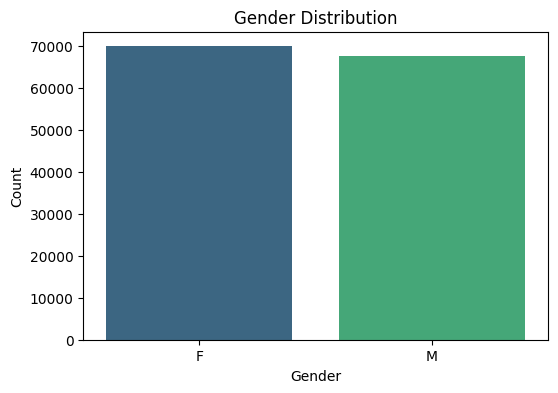

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_viz, x='gender', hue='gender', palette='viridis', legend=False)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

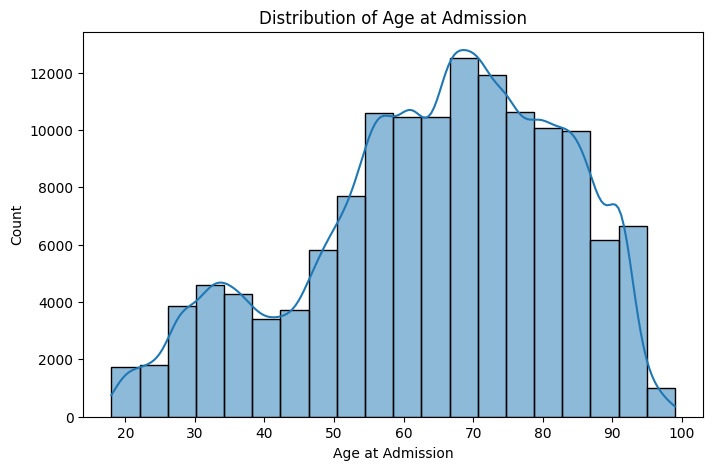

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_viz, x='age_at_admit', bins=20, kde=True)
plt.title('Distribution of Age at Admission')
plt.xlabel('Age at Admission')
plt.ylabel('Count')
plt.show()

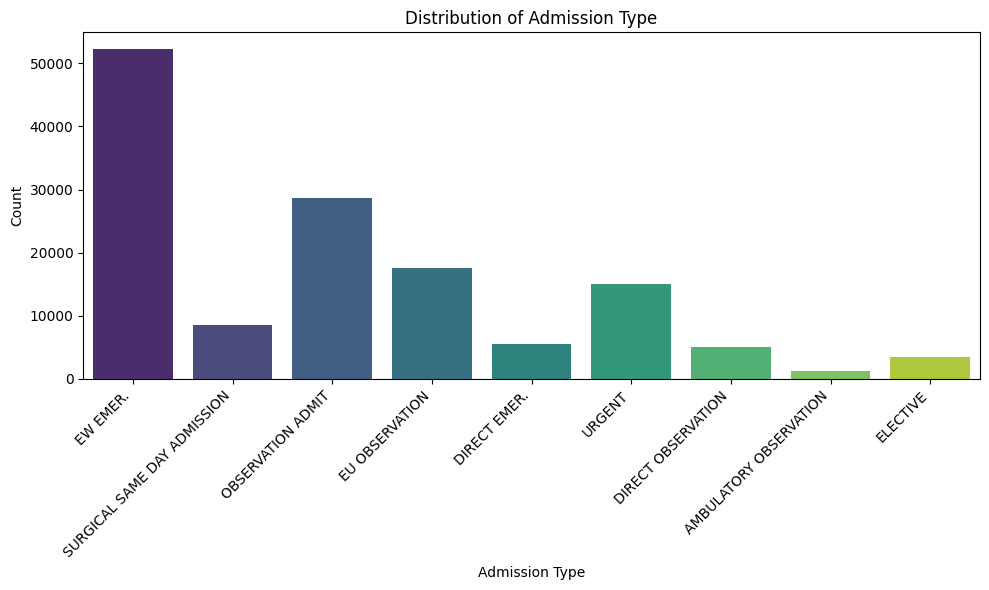

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_viz, x='admission_type', hue='admission_type', palette='viridis', legend=False)
plt.title('Distribution of Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

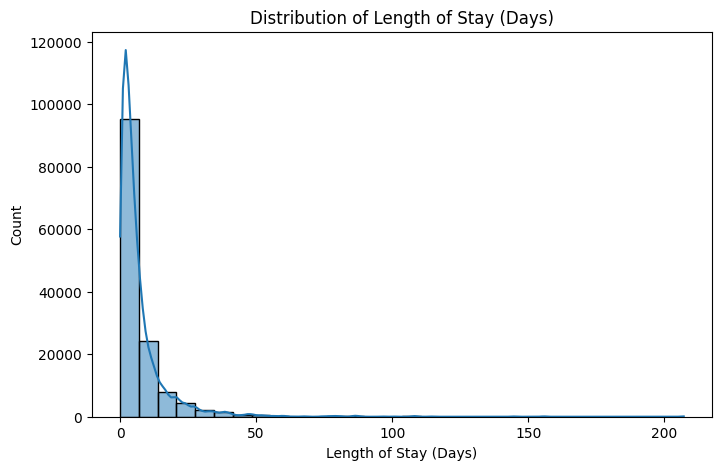

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_viz, x='los_days', bins=30, kde=True)
plt.title('Distribution of Length of Stay (Days)')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Count')
plt.show()

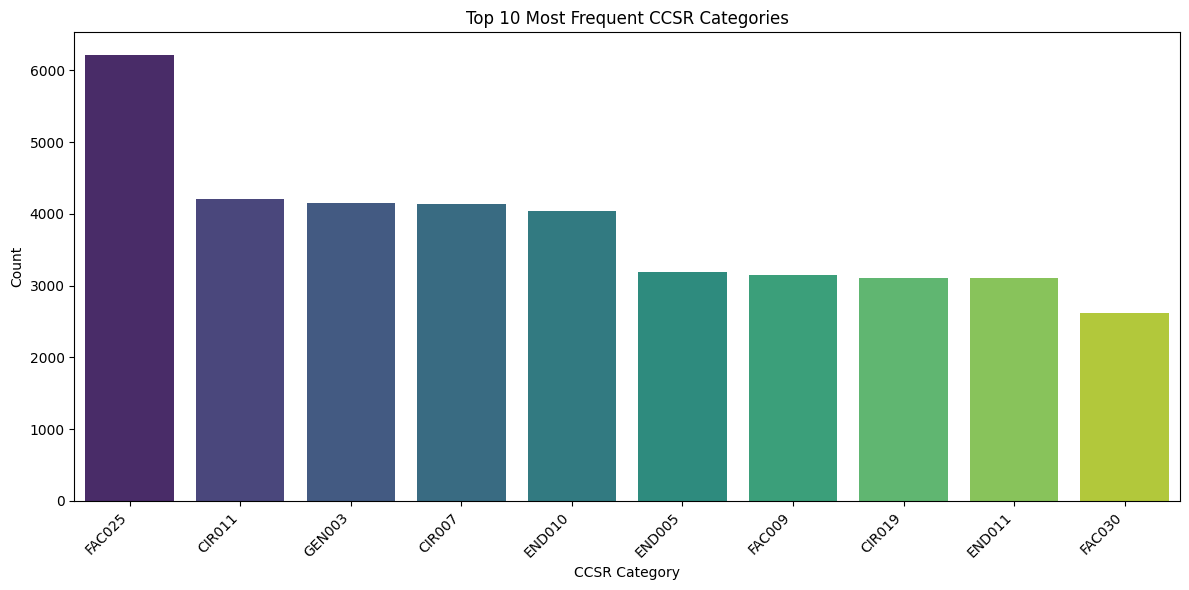

In [ ]:
from collections import Counter

# Flatten the list of CCSR categories
all_ccsr_categories = []
for ccsr_list_str in df_viz['ccsr_list_sorted']:
    try:
        # Safely evaluate the string as a Python literal (list)
        ccsr_list = ast.literal_eval(ccsr_list_str)
        if isinstance(ccsr_list, list):
            all_ccsr_categories.extend(ccsr_list)
    except (ValueError, SyntaxError):
        # Handle cases where the string is not a valid list literal
        pass

# Count the frequency of each category
ccsr_counts = Counter(all_ccsr_categories)

# Get the top 10 most frequent categories
top_10_ccsr = pd.DataFrame(ccsr_counts.most_common(10), columns=['CCSR_Category', 'Count'])

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_ccsr, x='CCSR_Category', y='Count', hue='CCSR_Category', palette='viridis', legend=False)
plt.title('Top 10 Most Frequent CCSR Categories')
plt.xlabel('CCSR Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Gender Distribution**: The patient population shows a relatively balanced gender distribution, with a slightly higher number of female patients compared to male patients.
*   **Age at Admission**: The age at admission is skewed towards older age groups, with a significant peak observed in the 70-90 year range, indicating that elderly patients constitute a large portion of admissions.
*   **Admission Type**: "EW EMER." (Emergency Ward Emergency) is the most prevalent admission type, suggesting a high volume of urgent and emergency-related patient entries.
*   **Length of Stay (LOS)**: The majority of hospital stays are relatively short, typically less than 10-15 days, with a sharp decrease in frequency for longer hospitalizations.
*   **Top 10 Most Frequent CCSR Categories**: The most common clinical conditions include `FAC025` (Other general symptoms), `CIR011` (Atherosclerosis and coronary heart disease), and `GEN003` (Other general signs and symptoms). Cardiovascular, endocrine, and general symptom-related conditions are highly prevalent.

### Insights or Next Steps

*   The high prevalence of emergency admissions and elderly patients, coupled with specific CCSR categories like cardiovascular and endocrine disorders, suggests a need for targeted healthcare programs and resources focusing on chronic disease management and emergency care for the aged population.
*   Further analysis could explore the correlation between age, admission type, length of stay, and specific CCSR categories to identify patient subgroups at higher risk for prolonged hospitalizations or specific complications.
